In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
from pred.data import data, continuous, categorical
from pred.NaiveBayes import NaiveBayesClassifier
from pred.LogisticRegression import MyLogisticRegression

datapath = "../data/adult.data.clean.csv"
d = data(datapath)
continuous_labels = list(continuous(d).keys())
categorical_labels = list(categorical(d).keys())
features = list(continuous_labels + categorical_labels)

NB = NaiveBayesClassifier(datapath)
LR = MyLogisticRegression(datapath)

For the Logistic Regression Model, list all features and corresponding coefficients.

In [76]:
# > 100 coefficients; one hot encoding expands the number of features
# ex: 'x0_Federal-gov' 'x0_Local-gov' 'x0_Private' 'x0_Self-emp-inc'
#  'x0_Self-emp-not-inc' 'x0_State-gov' 'x0_Without-pay' 'x1_10th' 'x1_11th'
# print(model.model.coef_)
# unwrap coefficients
import math 
from pprint import pprint

def sigmoid(x):
    return  (math.e**x)/(1+(math.e**x))

cont_coeff = {feature: [] for feature in continuous_labels}
cat_coeff = {feature: [] for feature in categorical_labels}
cat_names = LR.enc.get_feature_names_out()

# we can just use the first 5 continuous coefficients
for i in range(5):
    ft = features[i]
    cont_coeff[ft].append((ft, sigmoid(float(LR.model.coef_[0][i]))))

for i in range(len(cat_names)):
    ft_index = 5+int(cat_names[i].split('_')[0][1])
    ft = features[ft_index]
    ft_cat = cat_names[i].split('_')[1]

    val = LR.model.coef_[0][i+5]
    cat_coeff[ft].append((ft_cat, sigmoid(float(val))))

# sort
for i in range(len(categorical_labels)):
    ls = cat_coeff[categorical_labels[i]]
    ls.sort(key= lambda x: x[1])

coeffs = cont_coeff | cat_coeff

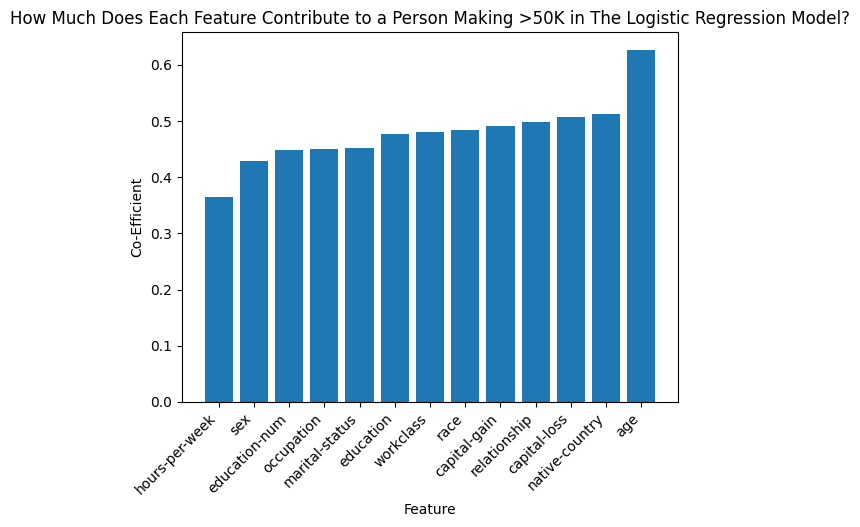

In [ ]:
Y = [sum(x[1] for x in coeffs[key])/len(coeffs[key]) for key in coeffs.keys()]

df = pd.DataFrame({
    'feature': coeffs.keys(),
    'coeff': Y
})
df = df.sort_values('coeff')
plt.bar(df['feature'], df['coeff'])
plt.xticks(rotation=45, ha='right')
plt.title('How Much Does Each Feature Contribute to a Person Making >50K in The Logistic Regression Model?')
plt.xlabel('Feature')
plt.ylabel('Co-Efficient')
plt.show()

In [84]:
import plotly.express as px

rows = []
for feature, entries in cat_coeff.items():
    if len(entries) >= 11:
        entries = entries[:5] + entries[-5:]
    for label, value in entries:
        rows.append({'feature': feature, 'category': label, 'value': value})

df = pd.DataFrame(rows)
px.treemap(df,path=['feature', 'category'],values='value',color='value',color_continuous_scale='curl_r', title="Breakdown: How Much Does Each Feature Contribute to a Person Making >50K in The Logistic Regression Model?")